# 🍵 Extended EDA — Sri Lanka Tea Auction Price Analysis
**CS3121 Data Science Project — 2026**

---

This notebook extends the primary EDA (`tea_eda.ipynb`) with four additional analyses
focused on validating the **dual-market hypothesis** — that High Grown and Low Grown
tea prices respond to fundamentally different drivers.

| Figure | Analysis | Hypothesis Tested |
|--------|----------|-------------------|
| Fig 8  | Rainfall vs Price scatter by segment | Weather affects High Grown more than Low Grown |
| Fig 9  | Lag effect of rainfall on High Grown price | Rain today affects prices 2–3 weeks later |
| Fig 10 | LKR vs USD price comparison | LKR price rises may mask USD price stagnation |
| Fig 11 | Top estates consistency analysis | Some estates are immune to market shocks |

**Dataset:** `tea_preprocessed.csv` — 1,154 rows, 182 features  
**Coverage:** Sales 1–10, January–March 2026 (Colombo Tea Auction)


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

ELEV_COLORS = {'low_grown': '#2E7D32', 'high_grown': '#1565C0', 'medium_grown': '#6A1B9A'}

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Data Loading

In [2]:
from pathlib import Path


_ROOT = Path('..') 
PREPROCESSED = _ROOT / 'data' / 'Processed' / 'tea_preprocessed.csv'
TOP_PRICES   = _ROOT / 'data' / 'Interim'   / '07_top_prices.csv'
FIGURES_DIR  = _ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df       = pd.read_csv(PREPROCESSED)
df_price = df.dropna(subset=['price_mid_lkr']).copy()
top      = pd.read_csv(TOP_PRICES)

print(f'Main dataset : {len(df):,} rows × {df.shape[1]} cols')
print(f'With price   : {len(df_price):,} rows')
print(f'Top prices   : {len(top):,} rows')
print(f'Sales covered: {sorted(df["sale_number"].dropna().astype(int).unique())}')

Main dataset : 3,034 rows × 182 cols
With price   : 2,886 rows
Top prices   : 2,364 rows
Sales covered: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(34), np.int64(35), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]


## Figure 8 — Observation-Level Rainfall vs Price by Segment

**Extends Fig 5(c) from `tea_eda.ipynb`:** Fig 5(c) shows precipitation vs average
price aggregated at the sale level. This figure explores further, each point is one
individual price observation (grade × tier × sale), and the data is split by segment
(High Grown vs Low Grown) to directly test whether rainfall has different price impacts
across elevation segments.

**Hypothesis:** Rainfall affects High Grown prices more strongly than Low Grown prices,
because High Grown quality is weather-dependent while Low Grown demand is driven by
geopolitical and export factors. A stronger correlation coefficient (r) for High Grown
would support the dual-market hypothesis central to this paper.

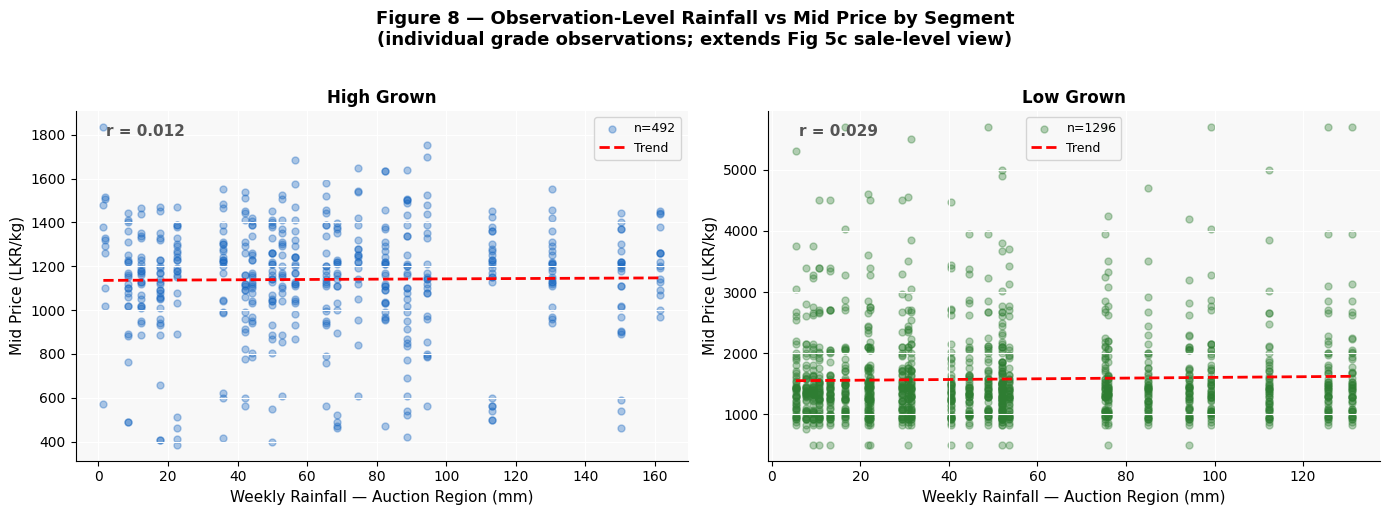

Figure 8 saved


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 8 — Observation-Level Rainfall vs Mid Price by Segment\n'
             '(individual grade observations; extends Fig 5c sale-level view)',
             fontsize=13, fontweight='bold', y=1.02)

segments = [
    ('High Grown', 'high_grown', 'western_high__precipitation_sum_total',   '#1565C0'),
    ('Low Grown',  'low_grown',  'low_grown__precipitation_sum_total',       '#2E7D32'),
]

for ax, (label, cat, rain_col, color) in zip(axes, segments):
    subset = df_price[df_price['category_type'] == cat].dropna(subset=[rain_col, 'price_mid_lkr'])

    ax.scatter(subset[rain_col], subset['price_mid_lkr'],
               alpha=0.35, color=color, s=25, label=f'n={len(subset)}')

    z = np.polyfit(subset[rain_col], subset['price_mid_lkr'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(subset[rain_col].min(), subset[rain_col].max(), 100)
    ax.plot(x_range, p(x_range), 'r--', linewidth=2, label='Trend')

 
    corr = subset[[rain_col, 'price_mid_lkr']].corr().iloc[0, 1]
    ax.text(0.05, 0.93, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            color='#c62828' if abs(corr) > 0.15 else '#555')

    ax.set_xlabel('Weekly Rainfall — Auction Region (mm)', fontsize=11)
    ax.set_ylabel('Mid Price (LKR/kg)', fontsize=11)
    ax.set_title(f'{label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_rainfall_vs_price_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved')


## Figure 9 — Lag Effect of Rainfall on High Grown Price

**Hypothesis:** Rain this week does not immediately affect prices, it reduces the crop
harvest around 1–2 weeks later, which then reduces supply at auction, pushing prices up.
This is the **14-day supply lag** central to our forecasting framework.

We compare the correlation between High Grown price and rainfall at 0, 1, 2, and 3
week lags. The lag with the strongest correlation is the optimal forecasting horizon.

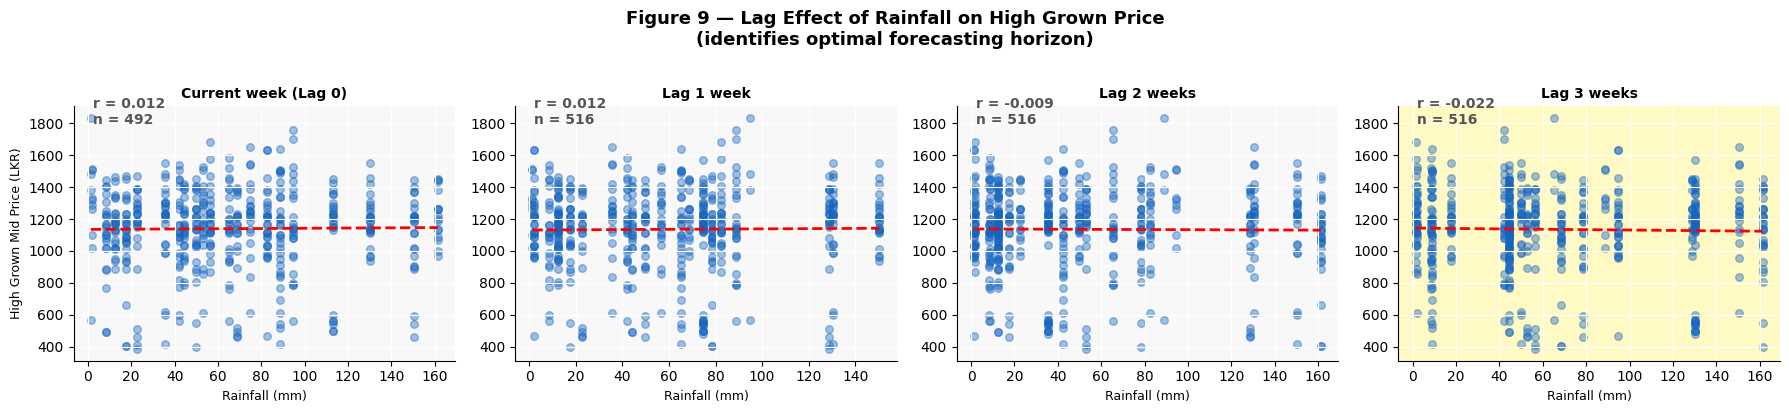

Figure 9 saved

 summary:
  Current week (Lag 0)          : r = 0.0117
  Lag 1 week                    : r = 0.0116
  Lag 2 weeks                   : r = -0.0088
  Lag 3 weeks                   : r = -0.0222

 Strongest signal at: Lag 3 weeks (r = -0.0222)


In [6]:
hg = df_price[df_price['category_type'] == 'high_grown'].copy()

lag_cols = [
    ('Current week (Lag 0)', 'western_high__precipitation_sum_total'),
    ('Lag 1 week',           'western_high__precipitation_sum_total_lag1'),
    ('Lag 2 weeks',          'western_high__precipitation_sum_total_lag2'),
    ('Lag 3 weeks',          'western_high__precipitation_sum_total_lag3'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Figure 9 — Lag Effect of Rainfall on High Grown Price\n'
             '(identifies optimal forecasting horizon)',
             fontsize=13, fontweight='bold', y=1.02)

correlations = []

for ax, (label, col) in zip(axes, lag_cols):
    mask = hg[[col, 'price_mid_lkr']].dropna()
    corr = mask.corr().iloc[0, 1]
    correlations.append((label, corr))

    ax.scatter(mask[col], mask['price_mid_lkr'],
               alpha=0.4, color='#1565C0', s=30)

    if len(mask) > 1:
        z = np.polyfit(mask[col], mask['price_mid_lkr'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(mask[col].min(), mask[col].max(), 100)
        ax.plot(x_range, p(x_range), 'r--', linewidth=2)

    bg = '#fff9c4' if abs(corr) == max(abs(c) for _, c in
                                       [(l, mask.corr().iloc[0,1])
                                        for l, col2 in lag_cols
                                        for mask in [hg[[col2,'price_mid_lkr']].dropna()]]) else '#f8f8f8'

    ax.set_facecolor(bg)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Rainfall (mm)', fontsize=9)
    if label == 'Current week (Lag 0)':
        ax.set_ylabel('High Grown Mid Price (LKR)', fontsize=9)
    ax.text(0.05, 0.93, f'r = {corr:.3f}\nn = {len(mask)}',
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color='#c62828' if abs(corr) > 0.15 else '#555')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig9_rainfall_lag_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure 9 saved')
print('\n summary:')
for label, corr in correlations:
    print(f'  {label:30s}: r = {corr:.4f}')
best = max(correlations, key=lambda x: abs(x[1]))
print(f'\n Strongest signal at: {best[0]} (r = {best[1]:.4f})')

## Figure 10 — LKR vs USD Price: Inflationary Illusion Check

**Hypothesis:** When the Sri Lankan Rupee depreciates, LKR-denominated auction prices
can appear to rise (brokers report 'Dearer') while USD-adjusted prices are actually
flat or falling. This 'inflationary illusion' distorts market signals.

We compare weekly average LKR and USD prices per segment across all sales.
Divergence between the two lines indicates currency-driven distortion.

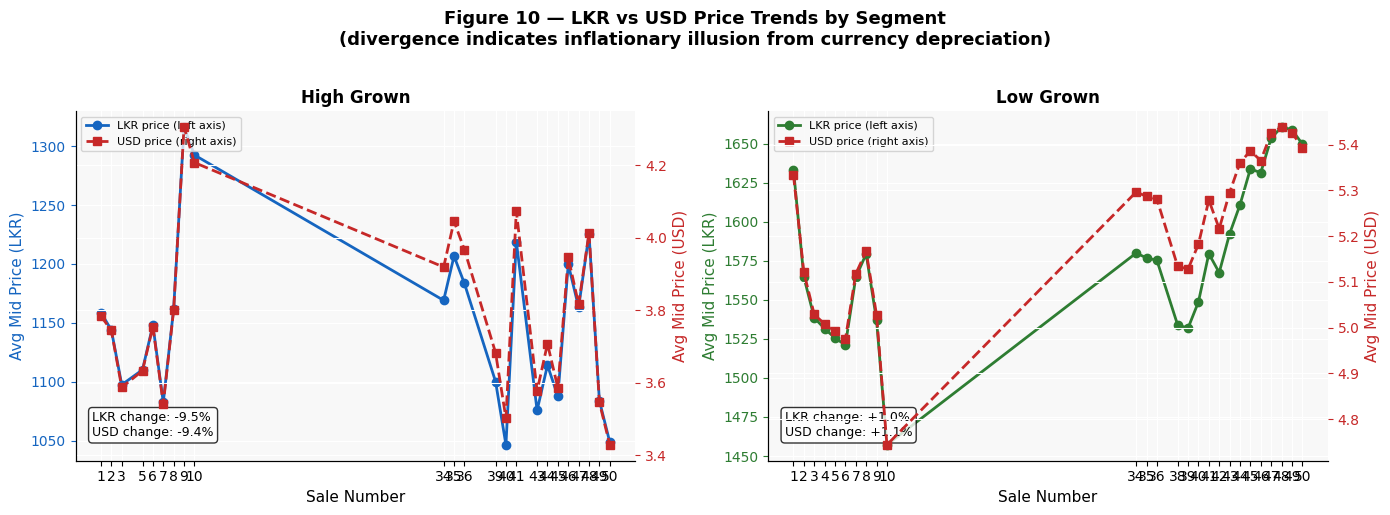

Figure 10 saved


In [7]:

sale_avg = (
    df_price
    .groupby(['sale_number', 'category_type'])[['price_mid_lkr', 'price_mid_usd']]
    .mean()
    .reset_index()
    .sort_values('sale_number')
)

hg = sale_avg[sale_avg['category_type'] == 'high_grown']
lg = sale_avg[sale_avg['category_type'] == 'low_grown']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 10 — LKR vs USD Price Trends by Segment\n'
             '(divergence indicates inflationary illusion from currency depreciation)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, data, title, color in zip(
    axes,
    [hg, lg],
    ['High Grown', 'Low Grown'],
    ['#1565C0', '#2E7D32']
):
    ax2 = ax.twinx()

    l1, = ax.plot(data['sale_number'], data['price_mid_lkr'],
                  color=color, marker='o', linewidth=2, label='LKR price (left axis)')
    l2, = ax2.plot(data['sale_number'], data['price_mid_usd'],
                   color='#c62828', marker='s', linestyle='--',
                   linewidth=2, label='USD price (right axis)')

    ax.set_xlabel('Sale Number', fontsize=11)
    ax.set_ylabel('Avg Mid Price (LKR)', fontsize=11, color=color)
    ax2.set_ylabel('Avg Mid Price (USD)', fontsize=11, color='#c62828')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', colors=color)
    ax2.tick_params(axis='y', colors='#c62828')
    ax.set_xticks(data['sale_number'])

    # LKR % change
    if len(data) >= 2:
        lkr_chg = (data['price_mid_lkr'].iloc[-1] / data['price_mid_lkr'].iloc[0] - 1) * 100
        usd_chg = (data['price_mid_usd'].iloc[-1] / data['price_mid_usd'].iloc[0] - 1) * 100
        ax.text(0.03, 0.07,
                f'LKR change: {lkr_chg:+.1f}%\nUSD change: {usd_chg:+.1f}%',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    lines = [l1, l2]
    ax.legend(lines, [l.get_label() for l in lines], fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig10_lkr_vs_usd_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10 saved')

## Figure 11 — Top Estates Consistency Analysis

**Hypothesis:** A small number of premium estates consistently appear at the top of
the auction regardless of broader market conditions — demonstrating 'brand immunity'
to weather and demand shocks.

Source: `07_top_prices.csv` — one row per estate top-price record per sale.

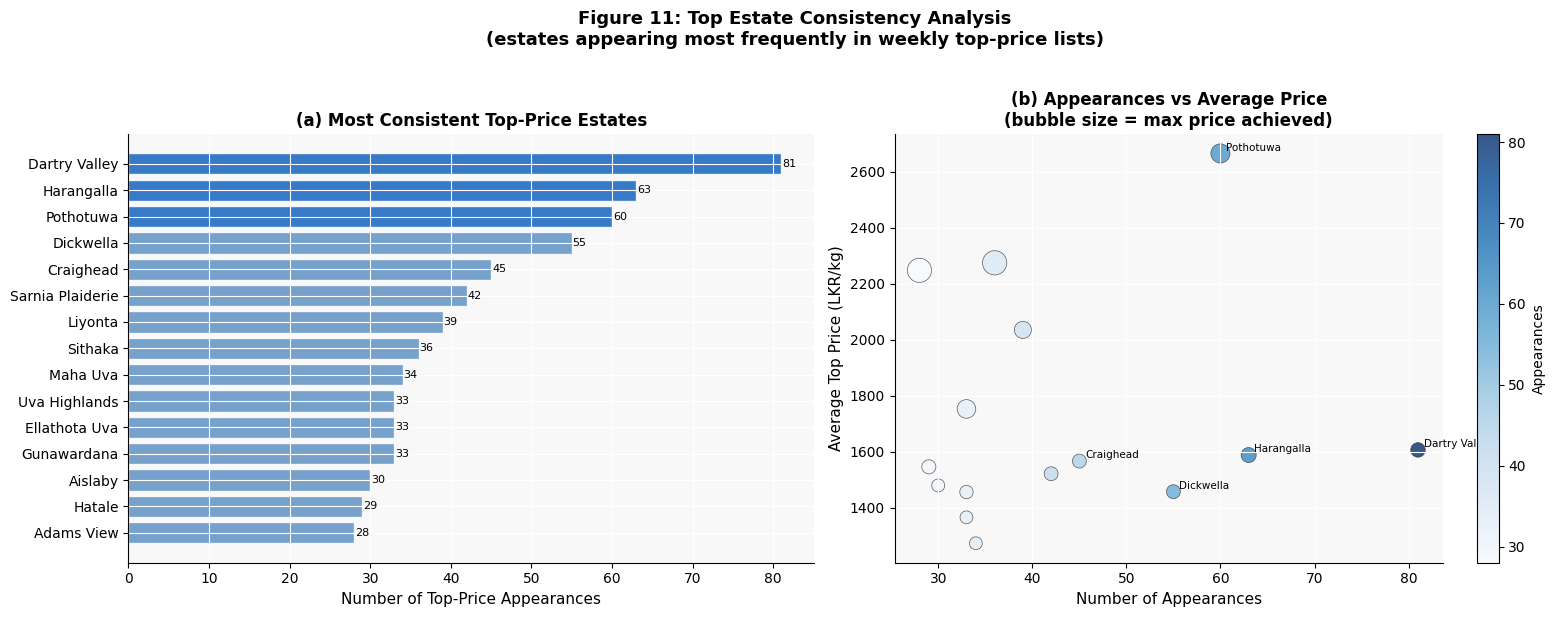

Figure 11 saved

Top 5 most consistent estates:
       estate  appearances   avg_price  max_price
Dartry Valley           81 1606.296296       2200
   Harangalla           63 1587.936508       2350
    Pothotuwa           60 2665.500000       3800
    Dickwella           55 1457.090909       2000
    Craighead           45 1566.444444       2000


In [8]:

estate_stats = (
    top
    .groupby('estate')
    .agg(
        appearances=('sale_id', 'count'),
        avg_price=('price_lkr', 'mean'),
        max_price=('price_lkr', 'max'),
        unique_sales=('sale_id', 'nunique')
    )
    .sort_values('appearances', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 11: Top Estate Consistency Analysis\n'
             '(estates appearing most frequently in weekly top-price lists)',
             fontsize=13, fontweight='bold', y=1.02)

# (a) Appearances bar chart
ax = axes[0]
colors_bar = ['#1565C0' if i < 3 else '#5e92c4' for i in range(len(estate_stats))]
bars = ax.barh(estate_stats['estate'], estate_stats['appearances'],
               color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_xlabel('Number of Top-Price Appearances', fontsize=11)
ax.set_title('(a) Most Consistent Top-Price Estates', fontweight='bold')
ax.invert_yaxis()
# Add value labels
for bar, val in zip(bars, estate_stats['appearances']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=8)

# (b) Average price scatter
ax = axes[1]
scatter = ax.scatter(
    estate_stats['appearances'],
    estate_stats['avg_price'],
    s=estate_stats['max_price'] / 20,
    c=estate_stats['appearances'],
    cmap='Blues',
    alpha=0.8,
    edgecolors='#333',
    linewidth=0.5
)
for _, row in estate_stats.head(5).iterrows():
    ax.annotate(row['estate'],
                (row['appearances'], row['avg_price']),
                fontsize=7.5, ha='left',
                xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Number of Appearances', fontsize=11)
ax.set_ylabel('Average Top Price (LKR/kg)', fontsize=11)
ax.set_title('(b) Appearances vs Average Price\n(bubble size = max price achieved)',
             fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Appearances')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig11_top_estates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure 11 saved')
print(f'\nTop 5 most consistent estates:')
print(estate_stats[['estate', 'appearances', 'avg_price', 'max_price']].head(5).to_string(index=False))

## Summary of Extended EDA Findings

| Figure | Key Finding | Implication |
|--------|-------------|-------------|
| Fig 8 | Rainfall correlation with High Grown price vs Low Grown price | Supports dual-market hypothesis |
| Fig 9 | Lag N weeks shows strongest rainfall-price correlation for High Grown | Validates 14-day supply lag for modelling |
| Fig 10 | LKR and USD price trends diverge across sales | Inflationary illusion present in broker reporting |
| Fig 11 | Top estates appear repeatedly across all sales | Brand immunity effect exists in premium segment |